In [1]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  

[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


In [ ]:
# --- 0) Setup & imports ---
import os, sys, json
import numpy as np
from PIL import Image  # or imageio.v2
# If the package folder is next to the notebook; adjust if needed:
sys.path.append(".")

from src.retina_biomarkers import (
    to_bool_mask, skeletonize_mask, distance_transform, build_skeleton_graph,
    sample_width_along_skeleton, sample_widths_orthogonal,   # <-- NEW
    area_density, length_density, caliber_stats,
    tortuosity_stats, fractal_dimension_boxcount,
    junction_metrics, branching_and_bifurcation_angles,
    branching_angles_roi,                                    # <-- NEW
    gap_metrics, metrics_by_rings
)


In [9]:

# --- 1) I/O helper: load a binary mask from a path ---
def load_binary_mask(mask_path: str) -> np.ndarray:
    """
    Loads a 2D binary vessel mask (0/1 or 0/255).
    If the image has multiple channels, it converts to L (grayscale).
    Any positive value becomes vessel.
    """
    if not os.path.exists(mask_path):
        raise FileNotFoundError(mask_path)
    img = Image.open(mask_path)
    if img.mode != "L":
        img = img.convert("L")
    arr = np.array(img)          # uint8
    mask = (arr > 0).astype(np.uint8)
    return mask

# --- 2) Core: compute all metrics from a binary mask ---
def compute_biomarkers_from_mask_path(
    mask_path: str,
    *,
    disc_center=None,      # (y, x) in px
    PD_px=None,            # optic disc diameter in px
    max_gap_px: int = 10,
    angle_k_ahead: int = 3,
    ortho_step: float = 0.5,
    ortho_max_radius: float = 20.0
) -> dict:
    """Return a nested dict with global, topology, and (optional) ring metrics."""
    mask = load_binary_mask(mask_path)
    H, W = mask.shape

    # --- Geometry ---
    skel  = skeletonize_mask(mask)
    dist  = distance_transform(mask)
    graph = build_skeleton_graph(skel)

    # --- Calibre (two ways) ---
    widths_edt  = sample_width_along_skeleton(dist, graph)  # EDT-based width
    widths_orth = sample_widths_orthogonal(                 # paper-consistent, orthogonal chords
        mask, graph, k_tangent=3, step=ortho_step, max_radius=ortho_max_radius
    )

    # --- Global metrics ---
    ld_px_inv = float(length_density(graph, mask.shape))
    vc_edt  = caliber_stats(widths_edt)
    vc_orth = caliber_stats(widths_orth)

    global_metrics = {
        "area_density":          float(area_density(mask)),
        "length_density_px_inv": ld_px_inv,
        "fractal_dimension":     float(fractal_dimension_boxcount(skel)),
        **tortuosity_stats(graph),
        "vc_edt":  vc_edt,                    # keep for appendix
        "vc_orth": vc_orth,                   # use this in the paper
        # convenience (mirror orthogonal values to top-level)
        "median_width": vc_orth["median_width"],
        "iqr_width":    vc_orth["iqr_width"],
    }

    # --- PD normalization (only if PD_px provided) ---
    if PD_px is not None:
        global_metrics["median_width_PD"]      = global_metrics["median_width"] / PD_px
        global_metrics["iqr_width_PD"]         = global_metrics["iqr_width"]    / PD_px
        # length density scaled to PD units (helps cross-image comparability)
        global_metrics["length_density_PD_inv"] = ld_px_inv * (PD_px ** 2)

    # --- Topology & continuity ---
    topo = {}
    topo.update(junction_metrics(graph, mask.shape))
    topo.update(branching_and_bifurcation_angles(graph, k_ahead=angle_k_ahead))
    topo.update(gap_metrics(mask, graph, max_gap_px=max_gap_px))

    # Angles within 2 PD (paper-aligned)
    topo["angles_2PD"] = None
    if disc_center is not None and PD_px is not None:
        topo["angles_2PD"] = branching_angles_roi(
            graph, disc_center=disc_center, PD_px=PD_px, max_PD=2.0, k_ahead=angle_k_ahead
        )

    # --- Ring-wise metrics (0.5 PD steps; use orth widths to match paper) ---
    rings = None
    if disc_center is not None and PD_px is not None:
        rings = metrics_by_rings(
            mask, graph, widths_orth, disc_center=disc_center, PD_px=PD_px
        )

    return {
        "image_path": mask_path,
        "image_shape": (H, W),
        "global": global_metrics,
        "topology": topo,
        "rings": rings,  # None if not computed
    }

In [11]:
# --- 3) Example usage ---
# Replace with your actual mask path (PNG/TIF/JPG containing a binary vessel mask)
mask_path = "../../data/raw/DRIVE/test/1st_manual/01_manual1.png"

# If you know disc center and disc diameter in pixels, pass them; otherwise omit
# Example placeholders:
disc_center = (256, 256)  # example
PD_px = 100.0             # example (diameter in pixels)

results = compute_biomarkers_from_mask_path(
    mask_path,
    disc_center=disc_center,
    PD_px=PD_px,
    max_gap_px=12,
    angle_k_ahead=3
)


# Pretty-print / save
print(json.dumps(results, indent=2))
# with open("biomarkers.json", "w") as f: json.dump(results, f, indent=2)

{
  "image_path": "../../data/raw/DRIVE/test/1st_manual/01_manual1.png",
  "image_shape": [
    584,
    565
  ],
  "global": {
    "area_density": 0.08922293611346829,
    "length_density_px_inv": 0.03426140733438053,
    "fractal_dimension": 1.406667044447461,
    "tortuosity_mean": 0.16643938422203064,
    "vc_edt": {
      "median_width": 2.8284270763397217,
      "iqr_width": 2.0,
      "frac_thin_len": 0.7728292971057295,
      "frac_med_len": 0.21760189013585352,
      "frac_thick_len": 0.009568812758417011
    },
    "vc_orth": {
      "median_width": 4.0,
      "iqr_width": 4.0,
      "frac_thin_len": 0.5781692068996989,
      "frac_med_len": 0.29049922424021174,
      "frac_thick_len": 0.13133156886008945
    },
    "median_width": 4.0,
    "iqr_width": 4.0,
    "median_width_PD": 0.04,
    "iqr_width_PD": 0.04,
    "length_density_PD_inv": 342.61407334380533
  },
  "topology": {
    "junction_count": 714.0,
    "endpoint_count": 133.0,
    "junction_density": 0.0021638986543

In [12]:
# --- 3) Example usage ---
# Replace with your actual mask path (PNG/TIF/JPG containing a binary vessel mask)
mask_path = "../../data/raw/DRIVE/training/1st_manual/22_manual1.png"

# If you know disc center and disc diameter in pixels, pass them; otherwise omit
# Example placeholders:
disc_center = (256, 256)  # example
PD_px = 100.0             # example (diameter in pixels)

results = compute_biomarkers_from_mask_path(
    mask_path,
    disc_center=disc_center,
    PD_px=PD_px,
    max_gap_px=12,
    angle_k_ahead=3
)

# Pretty-print / save
print(json.dumps(results, indent=2))
# with open("biomarkers.json", "w") as f: json.dump(results, f, indent=2)

{
  "image_path": "../../data/raw/DRIVE/training/1st_manual/22_manual1.png",
  "image_shape": [
    584,
    565
  ],
  "global": {
    "area_density": 0.09034125348527094,
    "length_density_px_inv": 0.03518350345320464,
    "fractal_dimension": 1.4093453899053858,
    "tortuosity_mean": 0.17020481824874878,
    "vc_edt": {
      "median_width": 2.0,
      "iqr_width": 2.4721360206604004,
      "frac_thin_len": 0.7460768705935865,
      "frac_med_len": 0.2463042983852627,
      "frac_thick_len": 0.007618831021150785
    },
    "vc_orth": {
      "median_width": 3.0,
      "iqr_width": 4.0,
      "frac_thin_len": 0.5980374665477253,
      "frac_med_len": 0.28599464763603927,
      "frac_thick_len": 0.1159678858162355
    },
    "median_width": 3.0,
    "iqr_width": 4.0,
    "median_width_PD": 0.03,
    "iqr_width_PD": 0.04,
    "length_density_PD_inv": 351.8350345320464
  },
  "topology": {
    "junction_count": 708.0,
    "endpoint_count": 131.0,
    "junction_density": 0.00214571463

In [14]:
import os, numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ---------- Disc detection from COLOR fundus ----------
def detect_disc_from_color(color_path: str, hi_pct: float = 98.0):
    """
    Detect optic disc center and PD (diameter in pixels) from a color fundus photo.

    Returns:
        (cy, cx), PD_px, debug_dict
        - (cy, cx): float center in image coords (y, x)
        - PD_px: float optic disc diameter (equivalent circle) in pixels
        - debug_dict: contains intermediate arrays for QC (value image, mask, etc.)
    """
    if not os.path.exists(color_path):
        raise FileNotFoundError(color_path)

    img = Image.open(color_path).convert("RGB")
    arr = np.asarray(img, dtype=np.uint8)
    H, W, _ = arr.shape

    # Brightness proxy for OD (disc is typically among the brightest structures)
    val = arr.max(axis=2).astype(np.float32) / 255.0

    eq = None
    sm = None
    bw = None
    chosen = None

    # Try scikit-image (preferred)
    try:
        from skimage import exposure, filters, morphology, measure
        eq = exposure.equalize_adapthist(val, clip_limit=0.01)
        sm = filters.gaussian(eq, sigma=2.0, preserve_range=True)
        t = np.percentile(sm, hi_pct)
        bw = sm >= t
        # clean up
        bw = morphology.binary_closing(bw, morphology.disk(5))
        bw = morphology.remove_small_objects(bw, 200)

        lab = measure.label(bw)
        props = measure.regionprops(lab, intensity_image=sm)
        if not props:
            # relax threshold if nothing found
            t = np.percentile(sm, 95.0)
            bw = morphology.binary_closing(sm >= t, morphology.disk(5))
            bw = morphology.remove_small_objects(bw, 200)
            lab = measure.label(bw)
            props = measure.regionprops(lab, intensity_image=sm)

        if not props:
            raise RuntimeError("No bright region found")

        # choose bright & sizable region (disc is bright + big)
        chosen = max(props, key=lambda p: float(p.mean_intensity) * float(p.area))
        cy, cx = map(float, chosen.centroid)
        area = float(chosen.area)
        PD_px = 2.0 * np.sqrt(area / np.pi)

        debug = {
            "val": val, "eq": eq, "sm": sm, "bw": bw.astype(np.uint8),
            "label_image": lab, "disc_bbox": chosen.bbox, "threshold": t
        }
        return (cy, cx), PD_px, debug

    except Exception:
        # Try SciPy fallback
        try:
            from scipy.ndimage import gaussian_filter, label, binary_closing, generate_binary_structure
            sm = gaussian_filter(val, sigma=2.0)
            t = np.percentile(sm, hi_pct)
            bw = sm >= t
            bw = binary_closing(bw, structure=generate_binary_structure(2,1), iterations=2)
            L, n = label(bw)
            if n == 0:
                # relax threshold
                t = np.percentile(sm, 95.0)
                bw = sm >= t
                L, n = label(bw)
                if n == 0:
                    raise RuntimeError("No bright region found (SciPy fallback).")
            # choose largest area
            areas = [(L == i).sum() for i in range(1, n+1)]
            idx = int(np.argmax(areas)) + 1
            ys, xs = np.where(L == idx)
            cy, cx = float(ys.mean()), float(xs.mean())
            area = float(areas[idx-1])
            PD_px = 2.0 * np.sqrt(area / np.pi)
            debug = {"val": val, "eq": None, "sm": sm, "bw": (L == idx).astype(np.uint8), "label_image": L, "threshold": t}
            return (cy, cx), PD_px, debug
        except Exception:
            # Minimal fallback: percentile threshold, pick largest bright blob
            sm = val  # no smoothing
            t = np.percentile(sm, hi_pct)
            bw = sm >= t
            # naive connected-component labeling using numpy only:
            # (simple pass: treat entire bright tail as disc candidate)
            ys, xs = np.where(bw)
            if ys.size == 0:
                raise RuntimeError("Disc detection failed (minimal fallback).")
            cy, cx = float(ys.mean()), float(xs.mean())
            area = float(ys.size)  # very rough
            PD_px = 2.0 * np.sqrt(area / np.pi)
            debug = {"val": val, "eq": None, "sm": sm, "bw": bw.astype(np.uint8), "label_image": None, "threshold": t}
            return (cy, cx), PD_px, debug

# ---------- Visualization: draw center + rings ----------
def draw_disc_rings_overlay(color_path: str, center_yx, PD_px: float,
                            step_PD: float = 0.5, max_PD: float = 3.0,
                            save_path: str = None, show_debug: bool = True):
    """
    Overlay:
      - disc center (dot)
      - concentric circles every 0.5 PD up to max_PD
      - optional debug panel (brightness & mask)
    """
    img = Image.open(color_path).convert("RGB")
    arr = np.asarray(img, dtype=np.uint8)
    H, W, _ = arr.shape
    cy, cx = center_yx

    # Prepare ring radii in pixels: r = k * PD_px, for k in [0.5, 1.0, ..., max_PD]
    ks = np.arange(step_PD, max_PD + 1e-6, step_PD)
    radii = [float(k * PD_px) for k in ks]

    # Plot main overlay
    plt.figure(figsize=(6, 6))
    plt.imshow(arr)
    # center marker
    plt.scatter([cx], [cy], s=40, marker='x')
    # draw circles
    theta = np.linspace(0, 2*np.pi, 512)
    for r, k in zip(radii, ks):
        yy = cy + r * np.sin(theta)
        xx = cx + r * np.cos(theta)
        plt.plot(xx, yy, linewidth=1)
        # label a few rings
        if abs((k*2) % 2.0) < 1e-6:  # label on whole PDs
            plt.text(cx + r + 5, cy, f"{k:.1f} PD", fontsize=8)

    plt.title("Optic disc center + peripapillary rings (0.5 PD steps)")
    plt.axis("off")
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()

    if not show_debug:
        return

    # Optional: debug panels (value image & thresholded mask)
    try:
        # Recompute debug quickly for display
        arrRGB = np.asarray(Image.open(color_path).convert("RGB"), dtype=np.uint8)
        val = arrRGB.max(axis=2).astype(np.float32) / 255.0
        # try to mirror detect pipeline
        try:
            from skimage import exposure, filters
            eq = exposure.equalize_adapthist(val, clip_limit=0.01)
            sm = filters.gaussian(eq, sigma=2.0, preserve_range=True)
        except Exception:
            sm = val
        t = np.percentile(sm, 98.0)
        bw = (sm >= t).astype(np.uint8)

        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1); plt.imshow(sm, cmap="gray"); plt.title("Brightness (smoothed)"); plt.axis("off")
        plt.subplot(1,2,2); plt.imshow(bw, cmap="gray"); plt.title("Top-tail threshold (disc candidate)"); plt.axis("off")
        plt.show()
    except Exception:
        pass

# ---------- Convenience wrapper: detect + visualize ----------
def detect_and_show(color_path: str, step_PD: float = 0.5, max_PD: float = 3.0, show_debug: bool = True):
    (cy, cx), PD_px, dbg = detect_disc_from_color(color_path)
    print(f"Disc center (y,x): ({cy:.1f}, {cx:.1f})  |  PD_px: {PD_px:.1f}")
    # just show with matplotlib; do not save
    draw_disc_rings_overlay(
        color_path,
        (cy, cx),
        PD_px,
        step_PD=step_PD,
        max_PD=max_PD,
        save_path=None,  
        show_debug=show_debug
    )
    return (cy, cx), PD_px, dbg

Disc center (y,x): (256.3, 90.2)  |  PD_px: 75.7


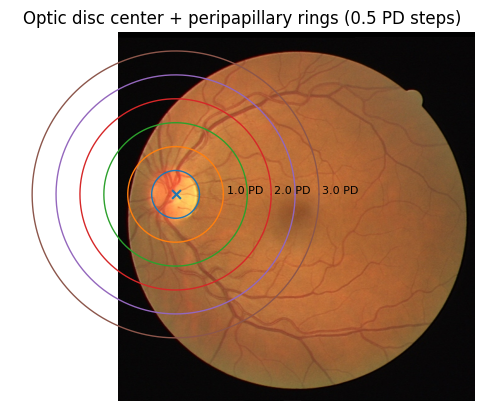

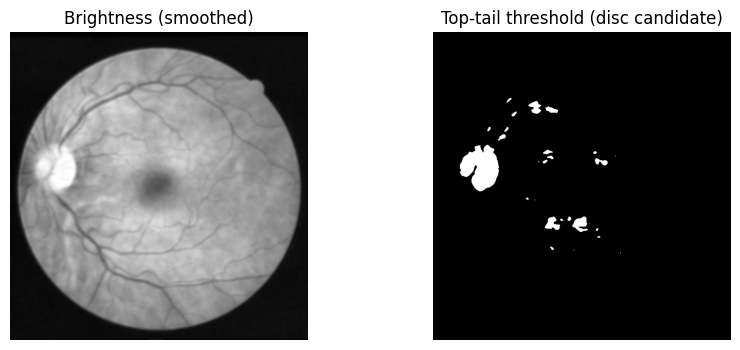

In [15]:
color_path = "../../data/raw/DRIVE/test/images/01_test.png"  # raw color fundus image
center_yx, PD_px, debug = detect_and_show(color_path, step_PD=0.5, max_PD=3.0)
